In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score 
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
DATA_DIR_4 = Path("XGBoost_numpy_192_dataset")
DATA_DIR_50 = Path("XGBoost_numpy_192_50_dataset")

#### Class Classification 

#### Loading the dataset from the saved numpy

In [3]:
X_train = np.load(DATA_DIR_4 / "X_train_192.npy")
y_train = np.load(DATA_DIR_4/ "y_train_192.npy")

X_test = np.load(DATA_DIR_4 / "X_test_192.npy")
y_test = np.load(DATA_DIR_4 / "y_test_192.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (258965, 192)
y_train: (258965,)
X_test: (110928, 192)
y_test: (110928,)


In [4]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)

In [5]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


#### Prediction of the test set

In [6]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (110928,)
Predicted classes: [0 1 2 3]


#### Evaluation metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.7587
Accuracy: 75.87%
Balanced_accuracy: 0.7490211542850607


In [9]:
print(classification_report(y_test, y_pred, target_names=["DoS", "Spoofing", "Fuzzing", "Replay"]))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

              precision    recall  f1-score   support

         DoS       0.85      0.80      0.83     27572
    Spoofing       0.61      0.79      0.69     18914
     Fuzzing       0.75      0.77      0.76     45143
      Replay       0.87      0.63      0.73     19299

    accuracy                           0.76    110928
   macro avg       0.77      0.75      0.75    110928
weighted avg       0.77      0.76      0.76    110928

Macro F1: 0.7520008721157004


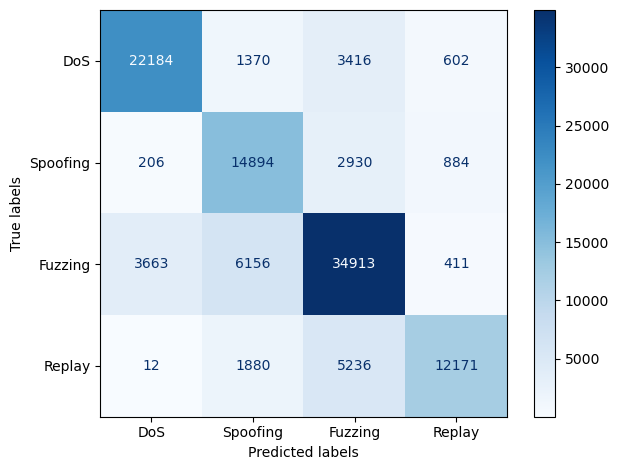

In [10]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DoS", "Spoofing", "Fuzzing", "Replay"])

display.plot(cmap="Blues", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

##### Random Forest comparison (same 192d SSL features)

Train a **Random Forest** on the same train/test split as XGBoost above.

In [17]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=4,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)
print(random_forest_model)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=4, random_state=42)


Random Forest with the same exact parameters as XGBoost [RandomForestClassifier(max_depth=4, min_samples_leaf=2, n_estimators=300, n_jobs=4, random_state=42)] performs much worse than what it already did if we increased the depth of the trees [RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300, n_jobs=4, random_state=42)], so overall it underperforms much more than XGBoost making it a weaker model choice. 

In [18]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions:", y_pred_rf.shape)
print("Predicted classes:", np.unique(y_pred_rf))


Predictions: (110928,)
Predicted classes: [0 1 2 3]


#### Evaluation metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [19]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")

Accuracy: 0.7111
Accuracy: 71.11%
Balanced_accuracy: 0.669840627200933


Results when: Max_depth = 4 
```
Accuracy: 0.6203
Accuracy: 62.03%
Balanced_accuracy: 0.5231539872790958
```

In [20]:
print(classification_report(y_test, y_pred_rf, target_names=["DoS", "Spoofing", "Fuzzing", "Replay"]))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

              precision    recall  f1-score   support

         DoS       0.86      0.77      0.81     27572
    Spoofing       0.65      0.63      0.64     18914
     Fuzzing       0.65      0.81      0.72     45143
      Replay       0.81      0.46      0.59     19299

    accuracy                           0.71    110928
   macro avg       0.74      0.67      0.69    110928
weighted avg       0.73      0.71      0.71    110928

Macro F1: 0.6910053905106963


Results when: Max_depth = 4 

```
precision    recall  f1-score   support

         DoS       0.83      0.71      0.76     27572
    Spoofing       0.73      0.31      0.44     18914
     Fuzzing       0.53      0.88      0.66     45143
      Replay       0.75      0.19      0.31     19299

    accuracy                           0.62    110928
   macro avg       0.71      0.52      0.54    110928
weighted avg       0.68      0.62      0.59    110928

Macro F1: 0.5439492861231747
```

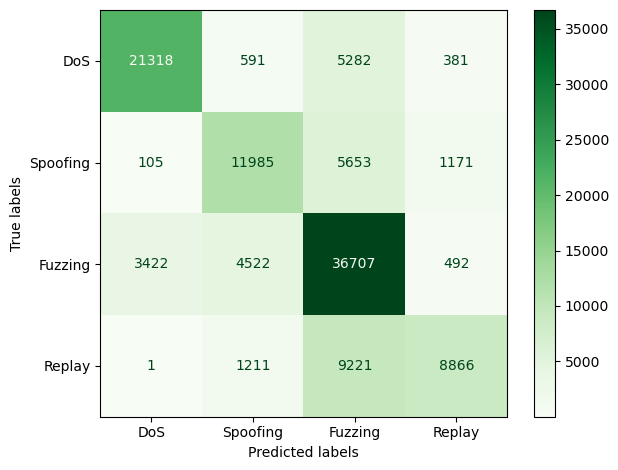

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DoS", "Spoofing", "Fuzzing", "Replay"])

display.plot(cmap="Greens", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

#### XGBoost vs Random Forest 15 Epoch 

In [22]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print()
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

XGBoost
Accuracy: 0.7587083513630463
Balanced_accuracy: 0.7490211542850607
Macro F1: 0.7520008721157004

Random Forest
Accuracy: 0.7110558199913457
Balanced_accuracy: 0.669840627200933
Macro F1: 0.6910053905106963


Results when: Max_depth = 4 

```
XGBoost
Accuracy: 0.7587083513630463
Balanced_accuracy: 0.7490211542850607
Macro F1: 0.7520008721157004

Random Forest
Accuracy: 0.6202942449156209
Balanced_accuracy: 0.5231539872790958
Macro F1: 0.5439492861231747
```

### 50 Epoch XGBoost 

Comparison of the second run but with longer epoch training 

In [16]:
X_train = np.load(DATA_DIR_4 / "X_train_192_50.npy")
y_train = np.load(DATA_DIR_4/ "y_train_192_50.npy")

X_test = np.load(DATA_DIR_4 / "X_test_192_50.npy")
y_test = np.load(DATA_DIR_4 / "y_test_192_50.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (258965, 192)
y_train: (258965,)
X_test: (110928, 192)
y_test: (110928,)


In [17]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)

In [18]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


#### Prediction of the test set

In [19]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (110928,)
Predicted classes: [0 1 2 3]


#### Evaluation metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.8038
Accuracy: 80.38%
Balanced_accuracy: 0.8427609153658806


In [21]:
print(classification_report(y_test, y_pred, target_names=["DoS", "Spoofing", "Fuzzing", "Replay"]))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

              precision    recall  f1-score   support

         DoS       0.73      0.86      0.79     27572
    Spoofing       0.71      0.97      0.82     18914
     Fuzzing       0.85      0.67      0.75     45143
      Replay       1.00      0.87      0.93     19299

    accuracy                           0.80    110928
   macro avg       0.82      0.84      0.82    110928
weighted avg       0.82      0.80      0.80    110928

Macro F1: 0.8220566379244518


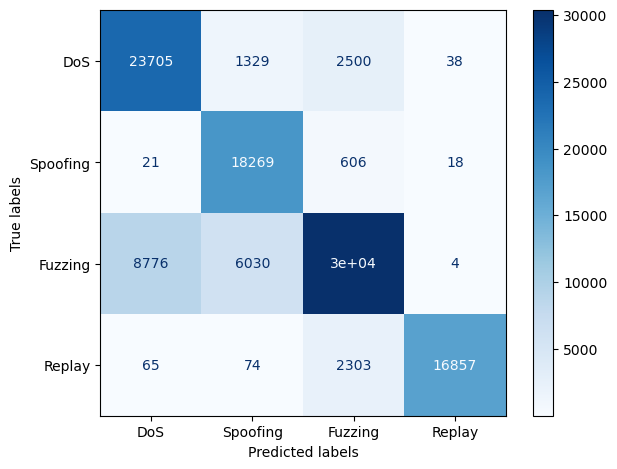

In [22]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DoS", "Spoofing", "Fuzzing", "Replay"])

display.plot(cmap="Blues", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

### 50 Epoch Random Forest 

Comparison of the second run but with longer epoch training 

In [23]:
X_train = np.load(DATA_DIR_4 / "X_train_192_50.npy")
y_train = np.load(DATA_DIR_4/ "y_train_192_50.npy")

X_test = np.load(DATA_DIR_4 / "X_test_192_50.npy")
y_test = np.load(DATA_DIR_4 / "y_test_192_50.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (258965, 192)
y_train: (258965,)
X_test: (110928, 192)
y_test: (110928,)


In [24]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=4,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)
print(random_forest_model)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=4, random_state=42)


In [25]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions:", y_pred_rf.shape)
print("Predicted classes:", np.unique(y_pred_rf))

Predictions: (110928,)
Predicted classes: [0 1 2 3]


#### Evaluation metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 

In [26]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")

Accuracy: 0.7030
Accuracy: 70.30%
Balanced_accuracy: 0.746619805305961


In [27]:
print(classification_report(y_test, y_pred_rf, target_names=["DoS", "Spoofing", "Fuzzing", "Replay"]))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

              precision    recall  f1-score   support

         DoS       0.66      0.82      0.73     27572
    Spoofing       0.62      0.95      0.75     18914
     Fuzzing       0.70      0.54      0.61     45143
      Replay       1.00      0.67      0.80     19299

    accuracy                           0.70    110928
   macro avg       0.75      0.75      0.72    110928
weighted avg       0.73      0.70      0.70    110928

Macro F1: 0.7244677040646246


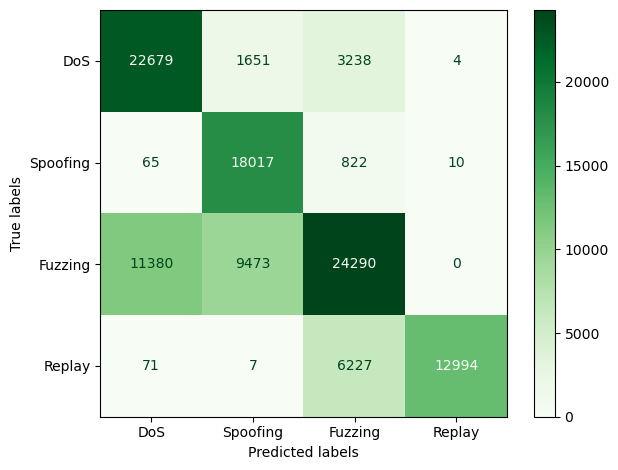

In [28]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DoS", "Spoofing", "Fuzzing", "Replay"])

display.plot(cmap="Greens", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

#### XGBoost vs Random Forest 50 Epoch 

In [30]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print()
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

XGBoost
Accuracy: 0.8038006634934372
Balanced_accuracy: 0.8427609153658806
Macro F1: 0.8220566379244518

Random Forest
Accuracy: 0.7029785085821434
Balanced_accuracy: 0.746619805305961
Macro F1: 0.7244677040646246
